# Online Neural CFR+

This notebook tests a separate neural CFR+ branch. Unlike the current Deep CFR setup, the regret network is trained on bootstrapped clipped cumulative regret targets:

```python
Q_t(I, a) = max(((t - 1) / t) * Q_{t-1}(I, a) + regret_t(I, a) / t, 0)
```

The deployed policy is still the learned average-strategy network. While specs are small enough, we also track an exact dense average of generated current policies as a diagnostic.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'liars_poker').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from liars_poker.core import GameSpec
from liars_poker.algo.deep_cfr_diagnostics import ExactDenseStrategyAverager
from liars_poker.algo.deep_cfr_plus import DeepCFRPlusTrainer
from liars_poker.training.deep_cfr_plus import (
    deep_cfr_plus_timed_loop,
    save_deep_cfr_plus_run,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('repo root:', REPO_ROOT)
print('device:', device)

repo root: c:\Users\adidh\Documents\liars_poker
device: cpu


In [18]:
spec = GameSpec(
    ranks=4,
    suits=4,
    hand_size=3,
    claim_kinds=('RankHigh', 'Pair', 'Trips'),
    suit_symmetry=True,
)

training_minutes = 30
eval_every = 5

trainer_kwargs = {
    'hidden_sizes': (256, 256),
    'device': device,
    'seed': 7,
    'regret_buffer_capacity': 100_000,
    'strategy_buffer_capacity': 100_000,
    'batch_size': 256,
    'regret_train_steps': 100,
    'strategy_train_steps': 50,
    'learning_rate': 1e-3,
    'regret_positive_weight': 0.5,
    'validation_fraction': 0.05,
    'validation_buffer_capacity': 10_000,
}

traversals_per_player = 100

print(spec)
print('short:', spec.to_short_str())
trainer_kwargs

GameSpec(ranks=4, suits=4, hand_size=3, claim_kinds=('RankHigh', 'Pair', 'Trips'), suit_symmetry=True)
short: r4_s4_h3_hpt_ss


{'hidden_sizes': (256, 256),
 'device': 'cpu',
 'seed': 7,
 'regret_buffer_capacity': 100000,
 'strategy_buffer_capacity': 100000,
 'batch_size': 256,
 'regret_train_steps': 100,
 'strategy_train_steps': 50,
 'learning_rate': 0.001,
 'regret_positive_weight': 0.5,
 'validation_fraction': 0.05,
 'validation_buffer_capacity': 10000}

In [19]:
exact_averager = ExactDenseStrategyAverager(spec)

policy, logs, trainer = deep_cfr_plus_timed_loop(
    spec,
    training_seconds=60 * training_minutes,
    trainer_kwargs=trainer_kwargs,
    traversals_per_player=traversals_per_player,
    eval_every=eval_every,
    exact_averager=exact_averager,
    debug=True,
)

print('iterations completed:', trainer.iteration)

[deep-cfr+] iter=1 training_budget=7.32/1800.00s traverse=3.46s fit=1.54s
[deep-cfr+] iter=2 training_budget=14.72/1800.00s traverse=3.35s fit=1.65s
[deep-cfr+] iter=3 training_budget=22.01/1800.00s traverse=3.42s fit=1.51s
[deep-cfr+] iter=4 training_budget=29.76/1800.00s traverse=3.78s fit=1.58s
[deep-cfr+] iter=5 training_budget=37.90/1800.00s traverse=3.71s fit=1.57s
[deep-cfr+] iter=6 training_budget=45.19/1800.00s traverse=3.55s fit=1.48s
[deep-cfr+] iter=7 training_budget=52.52/1800.00s traverse=3.45s fit=1.53s
[deep-cfr+] iter=8 training_budget=60.50/1800.00s traverse=3.88s fit=1.74s
[deep-cfr+] iter=9 training_budget=68.16/1800.00s traverse=3.88s fit=1.53s
[deep-cfr+] iter=10 training_budget=75.48/1800.00s traverse=3.42s fit=1.46s
[deep-cfr+] iter=11 training_budget=84.53/1800.00s traverse=4.77s fit=1.74s
[deep-cfr+] iter=12 training_budget=92.20/1800.00s traverse=3.78s fit=1.56s
[deep-cfr+] iter=13 training_budget=99.81/1800.00s traverse=3.74s fit=1.50s
[deep-cfr+] iter=14 tr

In [20]:
def exploitability_from_predicted_avg(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    return max(2.0 * float(x) - 1.0, 1e-8)


def exploitability_frame(logs):
    rows = []
    for point in logs.get('exploitability_series', []):
        elapsed = np.nan
        for record in reversed(logs.get('training_series', [])):
            if record.get('iteration') <= point['iter']:
                elapsed = record.get('elapsed_s', np.nan)
                break
        rows.append({
            'iter': point['iter'],
            'elapsed_s': elapsed,
            'learned_average': exploitability_from_predicted_avg(point.get('predicted_avg')),
            'current': exploitability_from_predicted_avg(point.get('current_predicted_avg')),
            'exact_average': exploitability_from_predicted_avg(point.get('exact_average_predicted_avg')),
        })
    return pd.DataFrame(rows)


def training_frame(logs):
    rows = []
    for record in logs.get('training_series', []):
        validation = record.get('validation', {})
        regret_val = validation.get('regret', [{}, {}])
        strategy_val = validation.get('strategy', [{}, {}])
        rows.append({
            'iteration': record['iteration'],
            'elapsed_s': record.get('elapsed_s', np.nan),
            'regret_loss': np.nanmean(record.get('regret_loss', [np.nan, np.nan])),
            'strategy_loss': np.nanmean(record.get('strategy_loss', [np.nan, np.nan])),
            'regret_mse': np.nanmean([v.get('mse', np.nan) for v in regret_val]),
            'regret_strategy_tv': np.nanmean([v.get('strategy_tv', np.nan) for v in regret_val]),
            'strategy_tv': np.nanmean([v.get('strategy_tv', np.nan) for v in strategy_val]),
            'traversal_s': record['timing']['traversal_s'],
            'regret_fit_s': record['timing']['regret_training_s'],
            'strategy_fit_s': record['timing']['strategy_training_s'],
            'regret_records_seen': sum(record.get('regret_records_seen', [0, 0])),
            'regret_records_retained': sum(record.get('regret_buffer_sizes', [0, 0])),
            'strategy_records_seen': sum(record.get('strategy_records_seen', [0, 0])),
            'strategy_records_retained': sum(record.get('strategy_buffer_sizes', [0, 0])),
        })
    return pd.DataFrame(rows)


exp_df = exploitability_frame(logs)
train_df = training_frame(logs)
exp_df.tail()

,iter,elapsed_s,learned_average,current,exact_average
46,235,1669.216812,0.124582,0.153764,0.119099
47,240,1703.622682,0.120646,0.151668,0.118321
48,245,1738.194260,0.119364,0.156342,0.117684
49,250,1773.489964,0.122795,0.148166,0.116958
50,254,1801.712538,0.120249,0.148744,0.116393


In [21]:
summary = pd.Series({
    'iterations completed': trainer.iteration,
    'final exact-average exploitability': exp_df['exact_average'].dropna().iloc[-1] if exp_df['exact_average'].notna().any() else np.nan,
    'best exact-average exploitability': exp_df['exact_average'].min(),
    'final learned-average exploitability': exp_df['learned_average'].dropna().iloc[-1] if exp_df['learned_average'].notna().any() else np.nan,
    'best learned-average exploitability': exp_df['learned_average'].min(),
    'final current exploitability': exp_df['current'].dropna().iloc[-1] if exp_df['current'].notna().any() else np.nan,
    'best current exploitability': exp_df['current'].min(),
    'final regret validation MSE': train_df['regret_mse'].dropna().iloc[-1] if train_df['regret_mse'].notna().any() else np.nan,
    'final regret-induced strategy TV': train_df['regret_strategy_tv'].dropna().iloc[-1] if train_df['regret_strategy_tv'].notna().any() else np.nan,
    'final average-network strategy TV': train_df['strategy_tv'].dropna().iloc[-1] if train_df['strategy_tv'].notna().any() else np.nan,
    'mean traversal s': train_df['traversal_s'].mean(),
    'mean regret fit s': train_df['regret_fit_s'].mean(),
    'mean strategy fit s': train_df['strategy_fit_s'].mean(),
})
summary.to_frame('neural CFR+')

,neural CFR+
iterations completed,254.000000
final exact-average exploitability,0.116393
best exact-average exploitability,0.116393
final learned-average exploitability,0.120249
best learned-average exploitability,0.119364
final current exploitability,0.148744
best current exploitability,0.144107
final regret validation MSE,0.025006
final regret-induced strategy TV,0.180369
final average-network strategy TV,0.054986


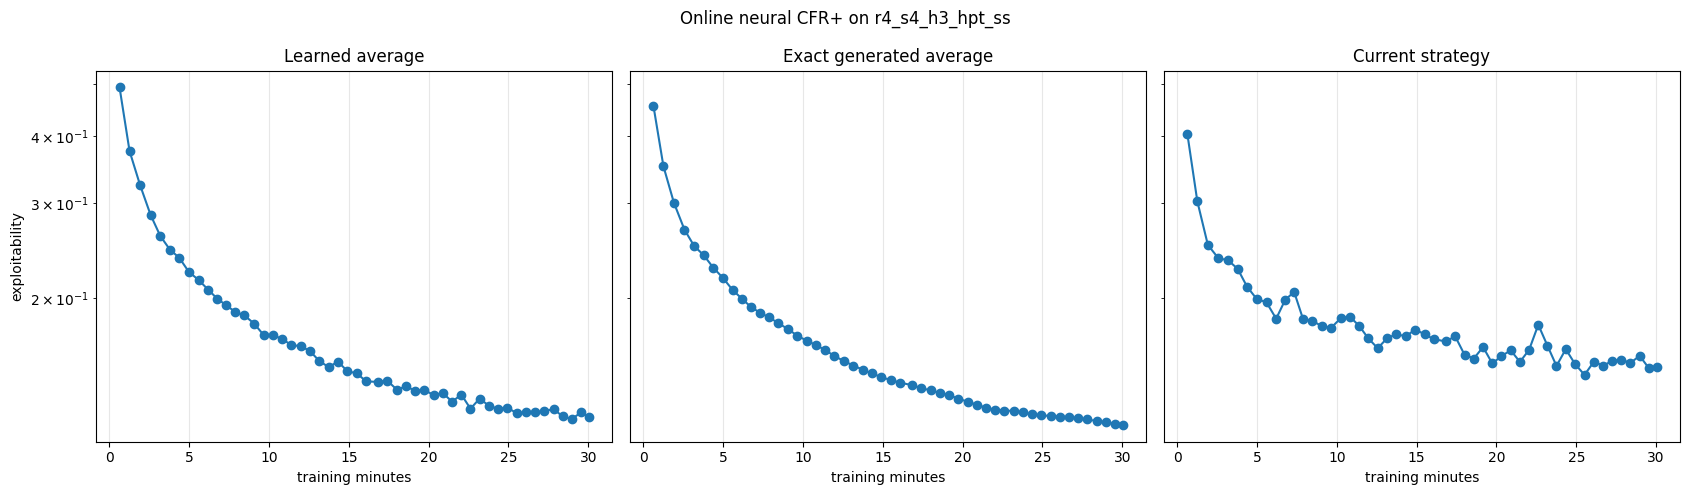

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, column, title in [
    (axes[0], 'learned_average', 'Learned average'),
    (axes[1], 'exact_average', 'Exact generated average'),
    (axes[2], 'current', 'Current strategy'),
]:
    ax.plot(exp_df['elapsed_s'] / 60.0, exp_df[column], marker='o')
    ax.set_yscale('log')
    ax.set_xlabel('training minutes')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('exploitability')
plt.suptitle(f'Online neural CFR+ on {spec.to_short_str()}')
plt.tight_layout()

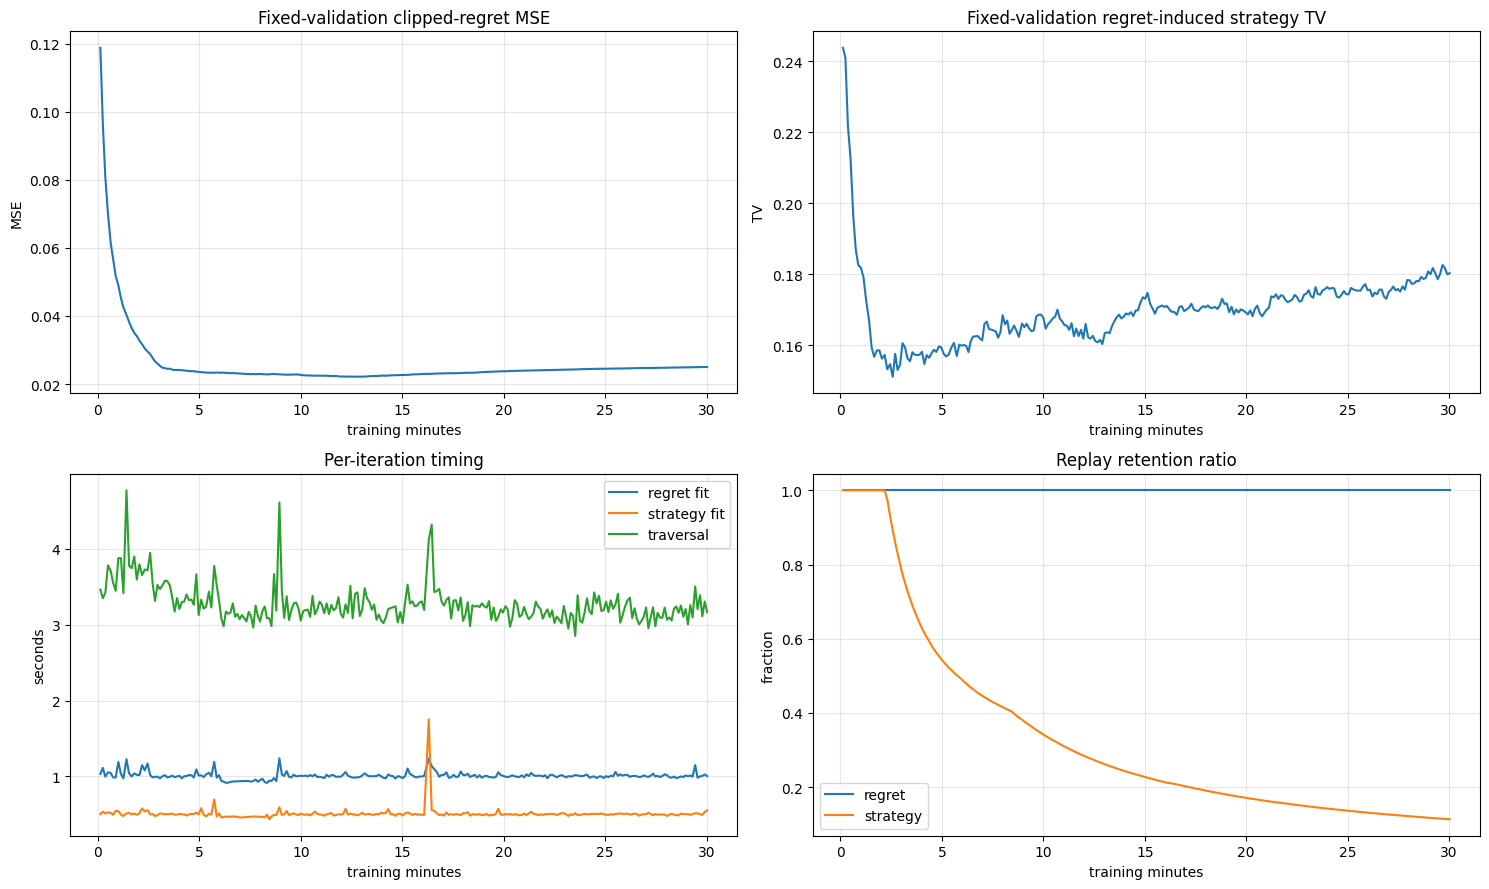

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(train_df['elapsed_s'] / 60.0, train_df['regret_mse'])
axes[0, 0].set_title('Fixed-validation clipped-regret MSE')
axes[0, 0].set_ylabel('MSE')

axes[0, 1].plot(train_df['elapsed_s'] / 60.0, train_df['regret_strategy_tv'])
axes[0, 1].set_title('Fixed-validation regret-induced strategy TV')
axes[0, 1].set_ylabel('TV')

axes[1, 0].plot(train_df['elapsed_s'] / 60.0, train_df['regret_fit_s'], label='regret fit')
axes[1, 0].plot(train_df['elapsed_s'] / 60.0, train_df['strategy_fit_s'], label='strategy fit')
axes[1, 0].plot(train_df['elapsed_s'] / 60.0, train_df['traversal_s'], label='traversal')
axes[1, 0].set_title('Per-iteration timing')
axes[1, 0].set_ylabel('seconds')
axes[1, 0].legend()

axes[1, 1].plot(train_df['elapsed_s'] / 60.0, train_df['regret_records_retained'] / train_df['regret_records_seen'].clip(lower=1), label='regret')
axes[1, 1].plot(train_df['elapsed_s'] / 60.0, train_df['strategy_records_retained'] / train_df['strategy_records_seen'].clip(lower=1), label='strategy')
axes[1, 1].set_title('Replay retention ratio')
axes[1, 1].set_ylabel('fraction')
axes[1, 1].legend()

for ax in axes.ravel():
    ax.set_xlabel('training minutes')
    ax.grid(True, alpha=0.3)
plt.tight_layout()

## Optional save

Use this only after a run you want to keep. It stores the playable average policy plus the full trainer checkpoint.

In [ ]:
# run_dir = REPO_ROOT / 'artifacts' / 'deep_cfr_plus_runs' / f'{spec.to_short_str()}___seed_{trainer_kwargs["seed"]}'
# save_deep_cfr_plus_run(run_dir, policy=policy, trainer=trainer, logs=logs)
# print(run_dir)